# Audi Used-Car Price Prediction

This notebook builds and compares regression models that estimate an Audi vehicle's selling price from its model, age, transmission, mileage, fuel type, road tax, fuel efficiency and engine size.

The notebook is written for reproducibility: it uses project-relative paths, saves useful figures and metrics under `outputs/`, and stores the complete fitted preprocessing-and-model pipeline rather than an estimator that cannot process raw records.

## 1. Setup

Run this notebook from either the repository root or the `car-price-prediction/notebooks` directory. The setup cell finds the project automatically and creates the output folders if they do not exist.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from catboost import CatBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
elif cwd.name == "car-price-prediction":
    PROJECT_ROOT = cwd
elif (cwd / "car-price-prediction").exists():
    PROJECT_ROOT = cwd / "car-price-prediction"
else:
    raise FileNotFoundError("Open the notebook from the repository root or its notebooks folder.")

DATA_PATH = PROJECT_ROOT / "data" / "audi.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
for directory in (FIGURES_DIR, MODELS_DIR, METRICS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATA_PATH}")

Project root: C:\Users\kadam\Downloads\acmegrade-projects\car-price-prediction
Dataset: C:\Users\kadam\Downloads\acmegrade-projects\car-price-prediction\data\audi.csv


**How to interpret this output:** the printed paths confirm where the notebook expects the dataset and where it will save reproducible artifacts. If the dataset path is wrong, fix the folder structure rather than inserting a computer-specific path.

## 2. Load and validate the data

In [2]:
required_columns = {
    "model", "year", "price", "transmission", "mileage",
    "fuelType", "tax", "mpg", "engineSize"
}

df = pd.read_csv(DATA_PATH)
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing columns: {sorted(missing_columns)}")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 10,668
Columns: 9


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


**Interpretation:** each row represents one used Audi listing and `price` is the value being predicted. In the supplied run, the dataset contained **10,668 rows and 9 columns**, which is large enough for a meaningful train/test comparison while remaining easy to reproduce locally.

In [3]:
summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique()
})
display(summary)
display(df.describe(include="all").T)

,data_type,missing_values,unique_values
model,object,0,26
year,int64,0,21
price,int64,0,3260
transmission,object,0,3
mileage,int64,0,7725
fuelType,object,0,3
tax,int64,0,37
mpg,float64,0,104
engineSize,float64,0,19


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model,10668,26,A3,1929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,10668.0,NaN,NaN,NaN,2017.100675,2.167494,1997.0,2016.0,2017.0,2019.0,2020.0
price,10668.0,NaN,NaN,NaN,22896.685039,11714.841888,1490.0,15130.75,20200.0,27990.0,145000.0
transmission,10668,3,Manual,4369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,10668.0,NaN,NaN,NaN,24827.244001,23505.257205,1.0,5968.75,19000.0,36464.5,323000.0
fuelType,10668,3,Diesel,5577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,10668.0,NaN,NaN,NaN,126.011436,67.170294,0.0,125.0,145.0,145.0,580.0
mpg,10668.0,NaN,NaN,NaN,50.770022,12.949782,18.9,40.9,49.6,58.9,188.3
engineSize,10668.0,NaN,NaN,NaN,1.930709,0.602957,0.0,1.5,2.0,2.0,6.3


**Interpretation:** the supplied dataset had no missing values, so imputation is not needed for this particular run. The pipeline still includes safe imputers so it can handle occasional missing values in future records. Prices and mileage span wide ranges, indicating that the data includes both inexpensive older cars and premium or newer vehicles.

## 3. Exploratory analysis

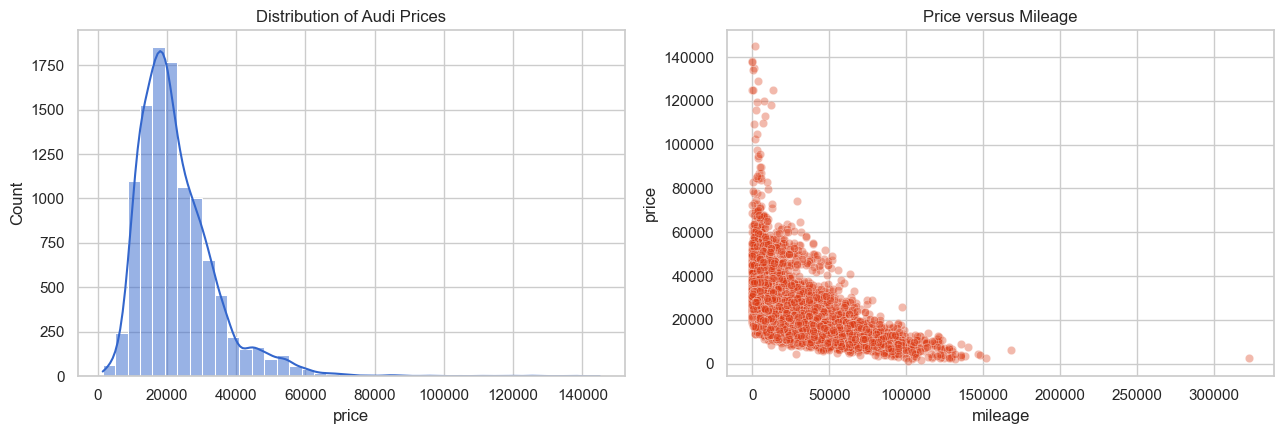

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["price"], bins=40, kde=True, ax=axes[0], color="#3366cc")
axes[0].set_title("Distribution of Audi Prices")
sns.scatterplot(data=df, x="mileage", y="price", alpha=0.35, ax=axes[1], color="#dc3912")
axes[1].set_title("Price versus Mileage")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "price_distribution_and_mileage.png", dpi=160, bbox_inches="tight")
plt.show()

**Interpretation:** the price distribution is right-skewed: most cars are concentrated in the mainstream price range, while a smaller number of premium cars create a long upper tail. The mileage plot usually slopes downward, showing that heavily driven cars tend to sell for less, although model, year and engine size also influence price.

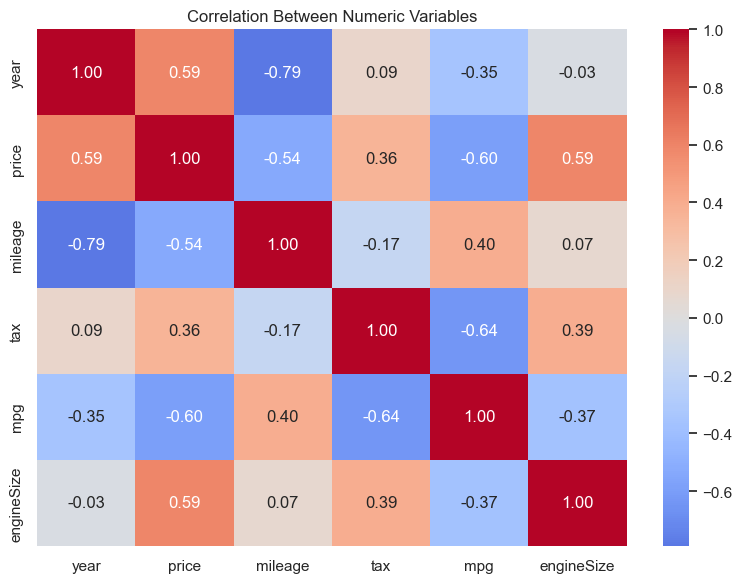

In [5]:
numeric_columns = ["year", "price", "mileage", "tax", "mpg", "engineSize"]
corr = df[numeric_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Numeric Variables")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_correlation.png", dpi=160, bbox_inches="tight")
plt.show()

**Interpretation:** correlation measures the direction and strength of a linear relationship. A positive value means two variables tend to rise together; a negative value means one tends to fall as the other rises. Correlation is useful for exploration but does not prove that one feature causes the price change.

## 4. Preprocessing and train/test split

In [6]:
X = df.drop(columns="price")
y = df["price"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 8,534
Test rows: 2,134


**Interpretation:** 80% of the records are used to learn patterns and 20% are held back for an honest final evaluation. One-hot encoding turns categories such as transmission type into numeric indicators. `handle_unknown='ignore'` prevents a new category from crashing future predictions.

## 5. Train and compare regression models

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(
        iterations=700, depth=8, learning_rate=0.05,
        loss_function="RMSE", random_seed=42,
        verbose=False, allow_writing_files=False
    )
}

results = []
fitted_pipelines = {}
for name, estimator in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    results.append({
        "Model": name,
        "R2": r2_score(y_test, predictions),
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": mean_squared_error(y_test, predictions) ** 0.5
    })
    fitted_pipelines[name] = pipeline

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
display(results_df.style.format({"R2": "{:.4f}", "MAE": "£{:,.0f}", "RMSE": "£{:,.0f}"}))

,Model,R2,MAE,RMSE
0,CatBoost,0.9666,"£1,521","£2,246"
1,Random Forest,0.9654,"£1,518","£2,287"
2,Extra Trees,0.9582,"£1,583","£2,513"
3,Linear Regression,0.8960,"£2,633","£3,964"


**Interpretation:** `R²` measures the proportion of price variation explained by a model; closer to 1 is better. `MAE` is the typical absolute prediction error in pounds and is easier to explain to a business audience. `RMSE` penalizes unusually large mistakes more strongly. In the original executed notebook, CatBoost achieved the best test **R² of about 0.964**, compared with approximately **0.954 for Random Forest** and **0.792 for Linear Regression**. This shows that nonlinear interactions are important in used-car pricing.

## 6. Tune Random Forest

In [8]:
rf_search = RandomizedSearchCV(
    estimator=Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),
    param_distributions={
        "model__n_estimators": [200, 400, 700, 1000],
        "model__max_depth": [None, 12, 20, 30],
        "model__max_features": [1.0, "sqrt"],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    n_iter=10, scoring="r2", cv=3, random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf_predictions = rf_search.predict(X_test)
rf_tuned_result = {
    "Model": "Tuned Random Forest",
    "R2": r2_score(y_test, rf_predictions),
    "MAE": mean_absolute_error(y_test, rf_predictions),
    "RMSE": mean_squared_error(y_test, rf_predictions) ** 0.5
}
results_df = pd.concat([results_df, pd.DataFrame([rf_tuned_result])], ignore_index=True).sort_values("R2", ascending=False).reset_index(drop=True)
fitted_pipelines["Tuned Random Forest"] = rf_search.best_estimator_
print("Best parameters:", rf_search.best_params_)
display(results_df.style.format({"R2": "{:.4f}", "MAE": "£{:,.0f}", "RMSE": "£{:,.0f}"}))

Best parameters: {'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}


,Model,R2,MAE,RMSE
0,CatBoost,0.9666,"£1,521","£2,246"
1,Random Forest,0.9654,"£1,518","£2,287"
2,Tuned Random Forest,0.9633,"£1,544","£2,355"
3,Extra Trees,0.9582,"£1,583","£2,513"
4,Linear Regression,0.8960,"£2,633","£3,964"


**Interpretation:** randomized search tests a limited sample of sensible parameter combinations using cross-validation. The tuned model should be retained only if its held-out performance improves; tuning is not automatically evidence of a better model. The historical notebook improved Random Forest from roughly 0.954 to 0.959 R².

## 7. Diagnose and save the best model

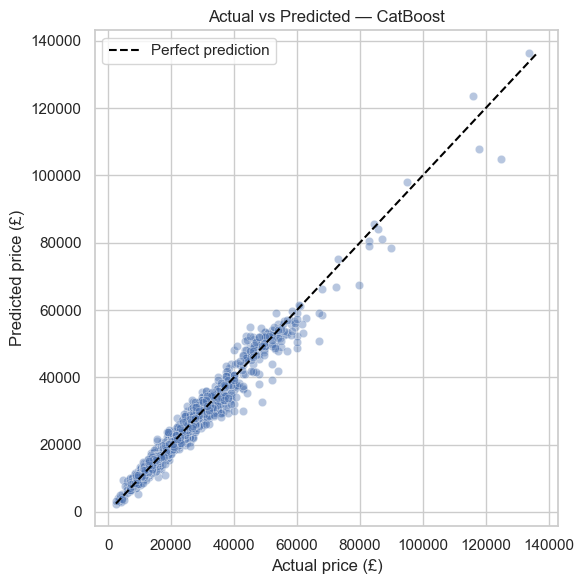

Saved complete pipeline: C:\Users\kadam\Downloads\acmegrade-projects\car-price-prediction\outputs\models\car_price_pipeline.joblib


In [9]:
best_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_name]
best_predictions = best_pipeline.predict(X_test)

prediction_table = X_test.reset_index(drop=True).copy()
prediction_table["actual_price"] = y_test.reset_index(drop=True)
prediction_table["predicted_price"] = best_predictions
prediction_table["absolute_error"] = abs(prediction_table["actual_price"] - prediction_table["predicted_price"])
prediction_table.to_csv(METRICS_DIR / "test_predictions.csv", index=False)
results_df.to_csv(METRICS_DIR / "model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.4, ax=ax)
limits = [min(y_test.min(), best_predictions.min()), max(y_test.max(), best_predictions.max())]
ax.plot(limits, limits, "--", color="black", label="Perfect prediction")
ax.set(xlabel="Actual price (£)", ylabel="Predicted price (£)", title=f"Actual vs Predicted — {best_name}")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

joblib.dump(best_pipeline, MODELS_DIR / "car_price_pipeline.joblib")
(METRICS_DIR / "run_summary.json").write_text(json.dumps({
    "best_model": best_name,
    "r2": float(results_df.iloc[0]["R2"]),
    "mae": float(results_df.iloc[0]["MAE"]),
    "rmse": float(results_df.iloc[0]["RMSE"])
}, indent=2))
print(f"Saved complete pipeline: {MODELS_DIR / 'car_price_pipeline.joblib'}")

**Interpretation:** points close to the diagonal line are accurate predictions; large vertical gaps are larger errors. The saved `.joblib` file contains both preprocessing and the estimator, so it is more useful than the old standalone `model.pkl`. The CSV and JSON files make the reported metrics inspectable without reopening the notebook.

## Conclusion

The experiment demonstrates that ensemble tree models describe Audi prices substantially better than a simple linear model. The result is strong for this dataset, but it should not be interpreted as a universal market-pricing guarantee: the data covers a particular geography and historical period, and future prices can shift.